## 1. Imports

In [1]:
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)

sns.set_style('whitegrid')
%matplotlib inline

## 2. Load the dataset


In [2]:
candidates = glob.glob('/kaggle/input/datasets/data855/heart-disease/heart.csv', recursive=True) + glob.glob('*.csv')

if not candidates:
    raise FileNotFoundError(
        'No CSV found. Make sure the dataset is added to this notebook '
        '(Add Data -> search "heart-disease" by data855).'
    )

csv_path = candidates[0]
print('Using file:', csv_path)

df = pd.read_csv(csv_path)
print('Shape:', df.shape)
df.head()

Using file: /kaggle/input/datasets/data855/heart-disease/heart.csv
Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 3. Explore the data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [5]:
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


### Identify the target column



In [6]:
print('Columns:', list(df.columns))

possible_targets = ['target', 'HeartDisease', 'heart_disease', 'output', 'num']
TARGET_COL = next((c for c in possible_targets if c in df.columns), df.columns[-1])
print('Target column detected as:', TARGET_COL)

df[TARGET_COL].value_counts()

Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
Target column detected as: target


target
1    165
0    138
Name: count, dtype: int64

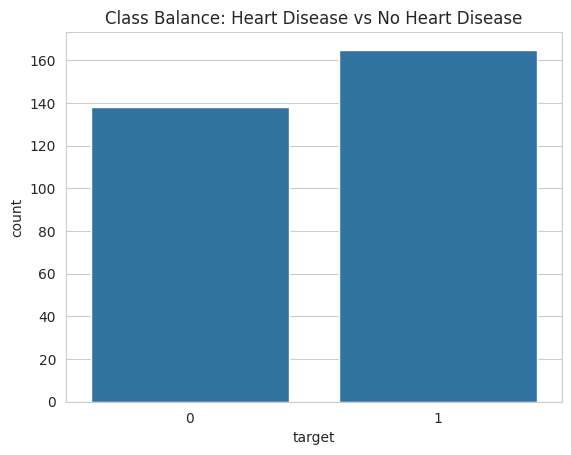

In [7]:
sns.countplot(x=TARGET_COL, data=df)
plt.title('Class Balance: Heart Disease vs No Heart Disease')
plt.show()

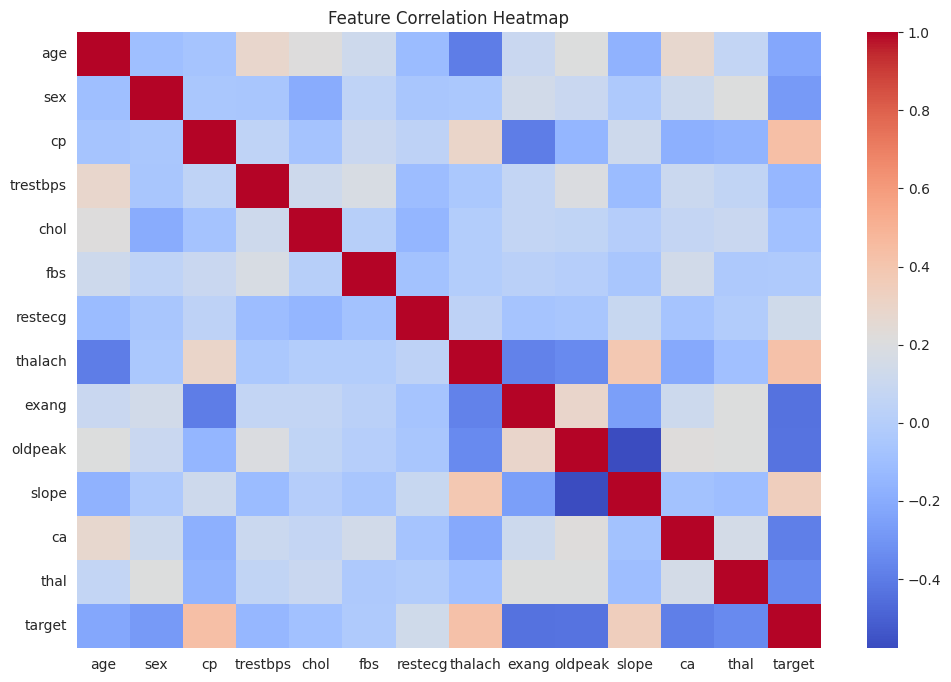

In [8]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

## 4. Preprocess the data

In [9]:
# Drop rows with missing target, fill missing feature values with median/mode
df = df.dropna(subset=[TARGET_COL]).copy()

for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype in ['float64', 'int64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

# Encode any categorical (object) columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
if cat_cols:
    print('Encoding categorical columns:', cat_cols)
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# If target itself became non-numeric text like 'Yes'/'No', encode it
if df[TARGET_COL].dtype == 'object':
    df[TARGET_COL] = df[TARGET_COL].astype('category').cat.codes

# Ensure binary target (some versions of this dataset use 0-4 severity scale)
if df[TARGET_COL].nunique() > 2:
    df[TARGET_COL] = (df[TARGET_COL] > 0).astype(int)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 5. Split into features/target and train/test sets

In [10]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (242, 13)
Test shape: (61, 13)


In [11]:
# Scale features (helps Logistic Regression converge and treats features fairly)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Train a classification model

We'll start with Logistic Regression (simple, interpretable baseline).

In [12]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

## 7. Evaluate the model

In [13]:
print('Accuracy: ', round(accuracy_score(y_test, y_pred), 3))
print('Precision:', round(precision_score(y_test, y_pred), 3))
print('Recall:   ', round(recall_score(y_test, y_pred), 3))
print('F1 Score: ', round(f1_score(y_test, y_pred), 3))
print('ROC AUC:  ', round(roc_auc_score(y_test, y_proba), 3))
print()
print(classification_report(y_test, y_pred))

Accuracy:  0.803
Precision: 0.769
Recall:    0.909
F1 Score:  0.833
ROC AUC:   0.869

              precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61



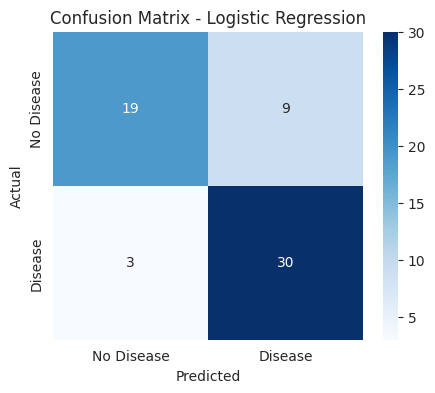

In [14]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

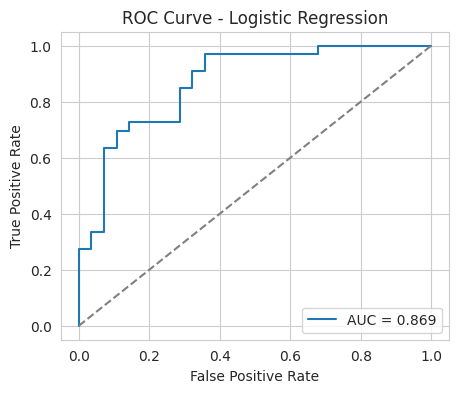

In [15]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba):.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()

## 8. (Bonus) Compare with Random Forest

A quick comparison against a second, more flexible algorithm.

In [16]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)  # tree models don't need scaling

rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print('Random Forest Accuracy:', round(accuracy_score(y_test, rf_pred), 3))
print('Random Forest ROC AUC: ', round(roc_auc_score(y_test, rf_proba), 3))
print()
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.82
Random Forest ROC AUC:  0.908

              precision    recall  f1-score   support

           0       0.95      0.64      0.77        28
           1       0.76      0.97      0.85        33

    accuracy                           0.82        61
   macro avg       0.85      0.81      0.81        61
weighted avg       0.85      0.82      0.81        61



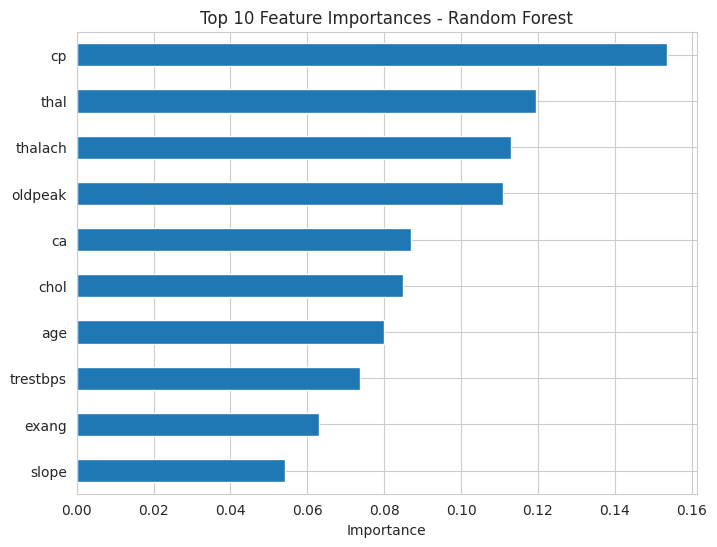

In [17]:
# Which features mattered most to the Random Forest?
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.show()